URL index: [Home](https://zzz.bwh.harvard.edu/luna-walkthrough/) | [Data](https://zzz.bwh.harvard.edu/luna-walkthrough/data/) | [S1. File QC](https://zzz.bwh.harvard.edu/luna-walkthrough/p1/) | [S2. Signal QC](https://zzz.bwh.harvard.edu/luna-walkthrough/p2) | [S3. Staging](https://zzz.bwh.harvard.edu/luna-walkthrough/p3) | [S4. Artifacts](https://zzz.bwh.harvard.edu/luna-walkthrough/p4) | [S5. Analysis](https://zzz.bwh.harvard.edu/luna-walkthrough/p5)

Notebook index: [Index](../00_index.ipynb) | [S1. File QC](../p1/00_index.ipynb) | [S2. Signal QC](../p2/00_index.ipynb) | [S3. Staging](../p3/00_index.ipynb) | [S4. Artifacts](../p4/00_index.ipynb) | [S5. Analysis](../p5/00_index.ipynb)

---

# 4.3. Hjorth plots

Walkthrough URL = [https://zzz.bwh.harvard.edu/luna-walkthrough/p4/hjorth/](https://zzz.bwh.harvard.edu/luna-walkthrough/p4/hjorth/)


In [2]:
import lunapi as lp
proj = lp.proj()
proj.sample_list( '../c.lst' )

initiated lunapi v1.2.3 <lunapi.lunapi0.luna object at 0x107a228f0> 

read 20 individuals from ../c.lst


He'll we pull and visually review further metrics from in the previous interpolation step.  __We won't recreate all plots from the original walk-through at this point using `lunapi`__ (although we do intend to add these visualizations in future iterations.  As always, be sure to follow the [original walk-through page](https://zzz.bwh.harvard.edu/luna-walkthrough/p4/hjorth/#final-maps) when looking at this notebook. 

## Preparatory steps

We'll first load the previously saved epoch-level Hjorth and CHEP masks from the prior step:

In [3]:
import pickle
with open('../tmp/ss.pkl', 'rb') as f: ss = pickle.load(f)
with open('../tmp/chep.pkl', 'rb') as f: chep = pickle.load(f)

We'll make two additional steps, that will help interpret the plots below:

 - extract stage information such that it can be easily aligned with the Hjorth statistics

 - calculate post-interpolation NREM-specific Hjorth metrics after bandpass filtering and epoch-masking

The second step here is to obtain metrics that would correspond to the signal data as typically used in analysis. We don't perform these steps as part of the previous generic QC pipeline, as different analyses may have different requirements. However, we often won't care about "artifact" if it is, e.g., specific to wake, falls outside the frequency range of interest, or is easily handled by dropping a small number of aberrant epochs.

First, we'll extract stages (and store in a dataframe called `stgs`):

In [8]:
# luna c.lst -o stages.db -s STAGE
res = proj.silent_proc( 'STAGE' ) 
stgs = proj.table('STAGE','E')

Second, we'll calculate filtered and epoch-masked Hjorth statistics (this will take several minutes):

In [9]:
# luna c.lst -o hjorth.db -s ' MASK ifnot=N2,N3 & RE
#                             CHEP-MASK ep-th=4,3 
#                             CHEP epochs & RE
#                             FILTER bandpass=0.3,35 tw=0.5,5 ripple=0.01,0.01
#                             SIGSTATS epoch ' 

res = proj.silent_proc( '''
  MASK ifnot=N2,N3 & RE
  CHEP-MASK ep-th=4,3
  CHEP epochs & RE
  FILTER bandpass=0.3,35 tw=0.5,5 ripple=0.01,0.01
  SIGSTATS epoch ''' )

In [10]:
u = proj.table( 'SIGSTATS' , 'CH_E' )
u

,ID,CH,E,H1,H2,H3
0,F09,AF3,4,185.975729,0.261554,0.662975
1,F09,AF3,5,213.423332,0.240825,0.63409
2,F09,AF3,6,139.067928,0.283204,0.652806
3,F09,AF3,7,165.005881,0.279305,0.655474
4,F06,AF3,8,348.124529,0.254468,0.742754
...,...,...,...,...,...,...
498289,M07,TP8,994,59.355027,0.270756,0.767034
498290,M07,TP8,995,59.106835,0.269428,0.785199
498291,M07,TP8,996,42.19996,0.286959,0.800288
498292,M07,TP8,997,39.954483,0.34543,0.736417


In [ ]:
#u <- ldb( "hjorth.db" )
#u <- u$SIGSTATS$CH_E
#u$H1 <- log( u$H1 ) 
#u$CH <- toupper( u$CH )
#u <- merge( u , ss , by=c("ID","E") )
#u <- merge( u , clocs[,c("CH","O")] , by= "CH" )

## CHEP mask plots

The `chep` dataframe contains a list of which channels where masked as bad for which epochs (including those for channels where the entire record was set as bad):

In [11]:
chep

,ID,CH,E,CHEP
0,F01,AF3,1,0
1,F02,AF3,1,0
2,F03,AF3,1,1
3,F04,AF3,1,0
4,F05,AF3,1,0
...,...,...,...,...
1025653,M07,TP8,994,0
1025654,M07,TP8,995,0
1025655,M07,TP8,996,0
1025656,M07,TP8,997,0


About 16% of channel/epoch pairs were flagged for interpolation:

In [13]:
chep.CHEP.value_counts()

CHEP
0    856071
1    169587
Name: count, dtype: int64

It can be useful to generate visual summaries of the epochs masked (as noted, this is similar information from the `INTERPOLATE` command). Here we'll generate a single plot for `F01`, where the black channel/epochs are those that were interpolated.  We'll use the same _heatmap_ function we defined in a previous notebook:

In [104]:
# define a quick heatmap function
from matplotlib.colors import Normalize
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

def heatmap( x, y, z, col=None, mt="", f=None, zero=None,
             zlim=None, legend=None , useRaster=True , epochs=None):

    if epochs is not None: 
        z = z.copy()
        z.loc[ epochs == False ] = np.nan
    
    x = np.asarray(x)
    y = np.asarray(y)
    z = np.asarray(z)

    if col is None: col = plt.cm.turbo
    if zero is not None: z[zero] = 0
    if f is None: f = np.ones_like(z, dtype=bool)

    x = x[f]
    y = y[f]
    z = z[f]

    # Validate square data
    nx = len(np.unique(x))
    ny = len(np.unique(y))
    nz = len(z)
    if nz == 0: raise ValueError("No data to plot")
    if nz != nx * ny: raise ValueError("Requires square data")

    # Sort data by y then x
    idx = np.lexsort((x, y))
    x = x[idx]
    y = y[idx]
    z = z[idx]

    # Compute z limits
    if zlim is None: zlim = [np.nanmin(z), np.nanmax(z)]

    # Convert to 2D matrix
    m = np.array(z).reshape((ny, nx))

    # Plot heatmap
    plt.figure(figsize=(14, 3))  # (width, height) in inches
    plt.imshow(
        m, origin='lower', cmap=col,
        aspect='auto', interpolation='nearest' if useRaster else 'none',
        extent=[min(x), max(x), min(y), max(y)],
        norm=Normalize(vmin=zlim[0], vmax=zlim[1])
    )
    plt.title(mt)
    plt.xticks([])
    plt.yticks([])

    plt.tight_layout()
    plt.show()

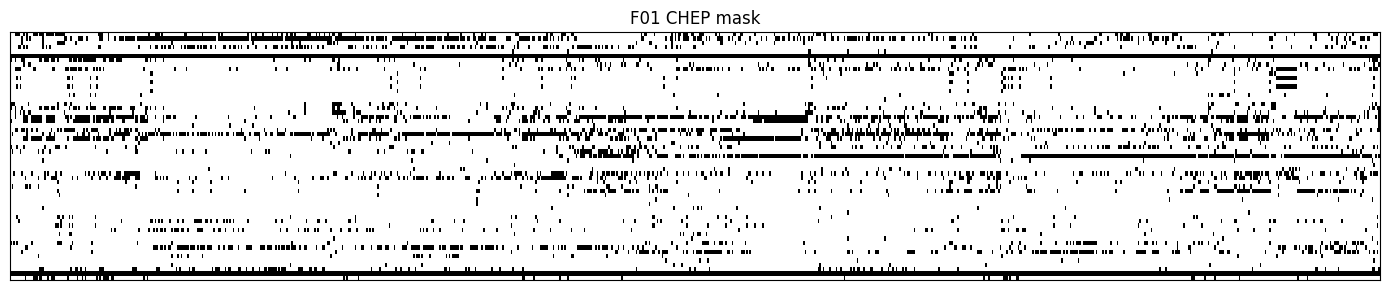

In [64]:
heatmap( chep.E, chep.CH, pd.to_numeric(chep.CHEP), 
         f = chep.ID == "F01" , mt = 'F01 CHEP mask', 
         col = plt.cm.binary , legend = None )

We'll skip the section of the revised matrix plots (2.0) for now, although this could be easily implemented in Python.

## Hjorth plots

We'll make a dataframe that combines the pre/post-imputation epoch-level Hjorth statistics with sleep stage information.

In [46]:
# extract 
stgs = stgs[['ID', 'E', 'OSTAGE']]
stgs = stgs.rename(columns={'OSTAGE': 'SS'})

KeyError: "['OSTAGE'] not in index"

In [132]:
# merge all together pre/post Hjorth stats (from ss), stages (from stgs) and post filtering and epoch removal also (from u)
d = pd.merge(ss, stgs, on=["ID", "E"])
u = u.rename(columns={'H1': 'H1QC', 'H2': 'H2QC', 'H3': 'H3QC' })
d = pd.merge(d, u, on=["ID", "E", "CH"], how="left")

# make numeric cols numeric
def safe_to_numeric(df):
    for col in df.columns:
        try:
            converted = pd.to_numeric(df[col], errors='coerce')
            # Only assign if at least one value successfully converts and the column isn't entirely NaN
            if not converted.isna().all():
                df[col] = converted
        except Exception:
            pass
    return df


In [133]:
d = safe_to_numeric(d)
# log-scale H1
d.H1 = np.log( d.H1 ) 

,ID,CH,E,INTERPOLATE,H1,H2,H3,SS,H1QC,H2QC,H3QC
0,F01,AF3,1,0,12.681152,0.022675,1.324543,W,NaN,NaN,NaN
1,F02,AF3,1,0,8.303459,0.243853,1.370869,W,NaN,NaN,NaN
2,F03,AF3,1,0,11.881204,0.091162,1.574155,W,NaN,NaN,NaN
3,F04,AF3,1,0,6.835710,0.166664,1.296263,W,NaN,NaN,NaN
4,F05,AF3,1,0,9.017023,0.057312,1.220481,W,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
2051311,M07,TP8,996,1,7.012956,0.065526,1.143173,N2,42.199960,0.286959,0.800288
2051312,M07,TP8,997,0,6.253985,0.108572,1.080250,N2,39.954483,0.345430,0.736417
2051313,M07,TP8,997,1,6.253985,0.108572,1.080250,N2,39.954483,0.345430,0.736417
2051314,M07,TP8,998,0,6.817419,0.078814,1.060287,N2,41.159220,0.330566,0.726119


### QC plots for F10

As an example, we'll generate plots for on individual (`F06`), for the second Hjorth parameter (`H2` or `H2QC`):

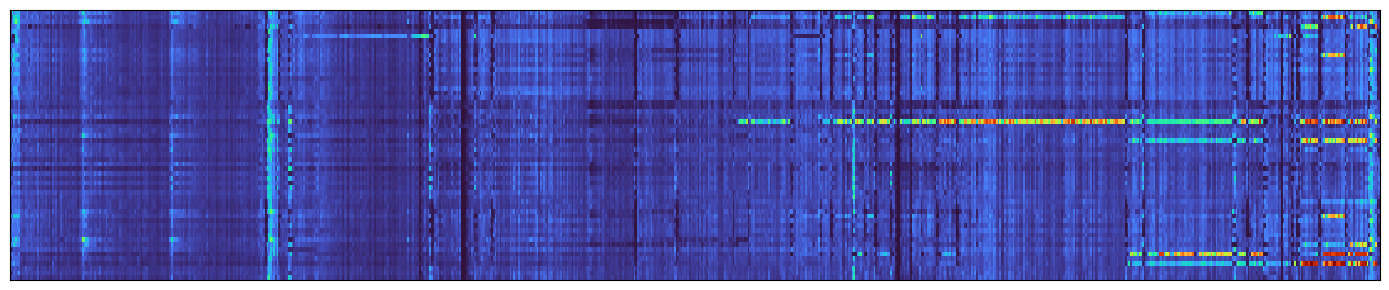

In [144]:
# pre-interpolation
heatmap( d.E , d.CH , d.H2 , f = ( d.ID == 'F06' ) & ( d.INTERPOLATE == 0 ) )

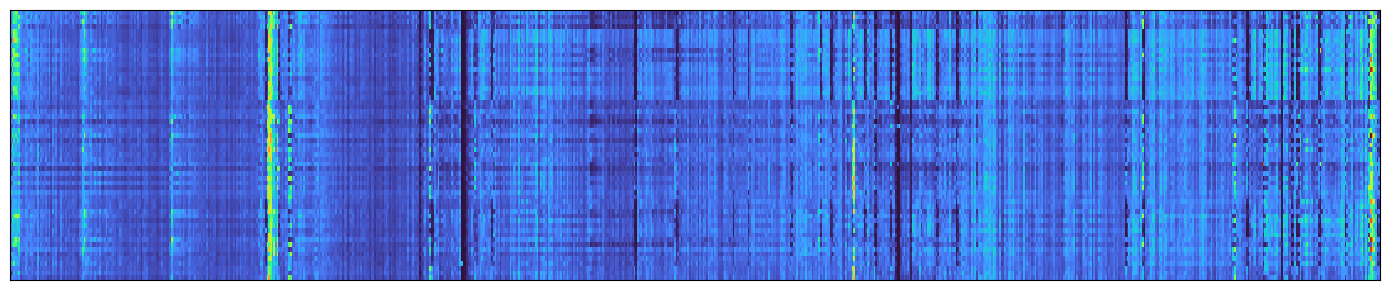

In [145]:
# post-interpolation
heatmap( d.E , d.CH , d.H2 , f = ( d.ID == 'F06' ) & ( d.INTERPOLATE == 1 ) )

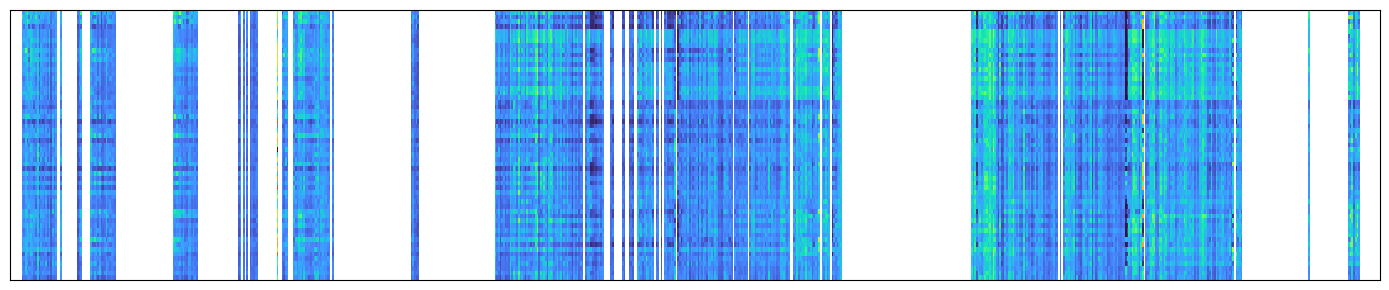

In [146]:
# post-interpolation N2 only
heatmap( d.E , d.CH , d.H2 , f = ( d.ID == 'F06' ) & ( d.INTERPOLATE == 1 ) , epochs = d.SS == 'N2'  )

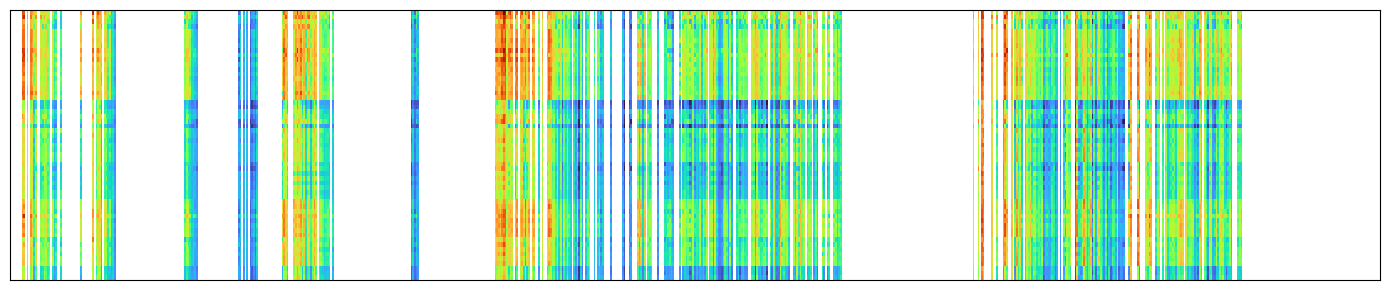

In [148]:
# post-interpolation N2 & QC+ only (note: dynamic range of z-axis changes here, in the filtered data)
heatmap( d.E , d.CH , d.H2QC , f = ( d.ID == 'F06' ) & ( d.INTERPOLATE == 1 ) , epochs = d.SS == 'N2'  )

Overall, the post-interpolation (sleep) dataset looks promising for embarking on actual analysis.

 - post-interpolation, we don't see the marked channel-specific artifact we saw in many pre-interpolation datasets

 - most remaining epoch-level artifact a) occurs during wake, and/or b) is outside the range of many sleep EEG analyses, and can therefore quite easily be handled by bandpass filtering, as above

 - even imposing epoch-level QC in which we remove an epoch if at least one of 57 channels is an outlier, the post-imputation data appear to be of sufficiently good quality that we are able to retain a very substantial proportion of NREM epochs for analysis (i.e. comparing the epochs removed betweem the third and fourth rows above)

Clearly, this is not intended to be the last word in EEG artifact detection and cleaning. Particular analyses may require more focused approaches (e.g. to detect/remove cardiac or muscle contamination in the EEG, etc).

---

However, what we have at this point appears sufficient for getting started on analysis based on the clean (`c.lst`) project. We can now move on to the [analysis steps](../p5/00_index.ipynb) of this walkthrough.